In [1]:
# Import the libraries
from transformers import RobertaTokenizer, RobertaModel
import torch

# Load RoBERTa
# This downloads the model first time (~500MB) — normal!
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model = RobertaModel.from_pretrained('roberta-base')

print("RoBERTa loaded successfully!")
print(f"Model has {sum(p.numel() for p in model.parameters()):,} parameters")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa loaded successfully!
Model has 124,645,632 parameters


In [2]:
# A fake news article sentence — our test input
text = "The president signed a historic peace deal with neighboring countries yesterday."

# Step 1 — Tokenize (convert words to numbers)
tokens = tokenizer(
    text,
    return_tensors='pt',    # return PyTorch tensors
    max_length=512,          # max tokens RoBERTa can handle
    truncation=True,
    padding=True
)

print("Original text:", text)
print("Token IDs shape:", tokens['input_ids'].shape)
print("Tokens:", tokens['input_ids'])

Original text: The president signed a historic peace deal with neighboring countries yesterday.
Token IDs shape: torch.Size([1, 14])
Tokens: tensor([[    0,   133,   394,  1419,    10,  3575,  1987,   432,    19, 10935,
           749,  2350,     4,     2]])


In [3]:
# Step 2 — Pass tokens through RoBERTa
with torch.no_grad():    # don't calculate gradients (we're not training)
    output = model(**tokens)

# Extract the [CLS] token vector — the sentence summary
cls_vector = output.last_hidden_state[:, 0, :]

print("All token vectors shape:", output.last_hidden_state.shape)
print("CLS vector shape:", cls_vector.shape)
print("First 5 values of CLS vector:", cls_vector[0][:5])

All token vectors shape: torch.Size([1, 14, 768])
CLS vector shape: torch.Size([1, 768])
First 5 values of CLS vector: tensor([-0.0677,  0.1476,  0.0146, -0.1363,  0.0588])


In [4]:
# Let's compare TWO sentences — similar meaning vs different meaning
sentence1 = "The president signed a peace agreement"
sentence2 = "The leader approved a peace treaty"      # same meaning, different words
sentence3 = "Scientists discovered a new species of fish"  # completely different

def get_cls_vector(text):
    tokens = tokenizer(
        text, 
        return_tensors='pt',
        max_length=512,
        truncation=True,
        padding=True
    )
    with torch.no_grad():
        output = model(**tokens)
    return output.last_hidden_state[:, 0, :]

# Get vectors for all 3
vec1 = get_cls_vector(sentence1)
vec2 = get_cls_vector(sentence2)
vec3 = get_cls_vector(sentence3)

# Measure similarity (cosine similarity — 1.0 = identical, 0.0 = different)
cos = torch.nn.CosineSimilarity(dim=1)

sim_1_2 = cos(vec1, vec2).item()
sim_1_3 = cos(vec1, vec3).item()

print(f"Sentence 1: {sentence1}")
print(f"Sentence 2: {sentence2}")
print(f"Sentence 3: {sentence3}")
print()
print(f"Similarity (1 vs 2 — same meaning): {sim_1_2:.4f}")
print(f"Similarity (1 vs 3 — different):    {sim_1_3:.4f}")

Sentence 1: The president signed a peace agreement
Sentence 2: The leader approved a peace treaty
Sentence 3: Scientists discovered a new species of fish

Similarity (1 vs 2 — same meaning): 0.9996
Similarity (1 vs 3 — different):    0.9984


Image created!
Image size: (224, 224)
Image mode: RGB


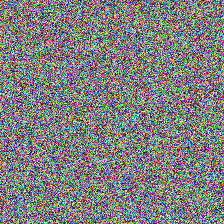

In [6]:
from PIL import Image
import numpy as np

# Create a simple test image (random pixels — just to test CLIP works)
random_image = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
image = Image.fromarray(random_image)

# Save it
image.save("test_image.jpg")

print("Image created!")
print("Image size:", image.size)
print("Image mode:", image.mode)
image

In [7]:
import open_clip

# Load CLIP model
clip_model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
clip_model.eval()

print("CLIP loaded successfully!")

# Step 1 — Preprocess the image
image_input = preprocess(image).unsqueeze(0)  # add batch dimension
print("Preprocessed image shape:", image_input.shape)

# Step 2 — Get image vector
with torch.no_grad():
    image_vector = clip_model.encode_image(image_input)

print("Image vector shape:", image_vector.shape)
print("First 5 values:", image_vector[0][:5])

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/opt/anaconda3/envs/sentinel_env/lib/python3.10/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP loaded successfully!
Preprocessed image shape: torch.Size([1, 3, 224, 224])
Image vector shape: torch.Size([1, 512])
First 5 values: tensor([ 0.0472, -0.3770,  0.0452, -0.1401, -0.1926])


In [8]:
# Let's see both our vectors side by side
print("=" * 50)
print("MODULE 1 — Current State")
print("=" * 50)
print(f"Text vector  (RoBERTa): {cls_vector.shape}  → {cls_vector[0][:3].tolist()}")
print(f"Image vector (CLIP):    {image_vector.shape} → {image_vector[0][:3].tolist()}")
print()
print("Problem: different sizes — 768 vs 512")
print("Solution: Cross-Modal Attention layer will fix this!")

MODULE 1 — Current State
Text vector  (RoBERTa): torch.Size([1, 768])  → [-0.06767532974481583, 0.14761224389076233, 0.014587010256946087]
Image vector (CLIP):    torch.Size([1, 512]) → [0.04717157408595085, -0.3769564926624298, 0.045186929404735565]

Problem: different sizes — 768 vs 512
Solution: Cross-Modal Attention layer will fix this!


In [9]:
import torch.nn as nn

class CrossModalAttention(nn.Module):
    def __init__(self, text_dim=768, image_dim=512, hidden_dim=256):
        super().__init__()
        
        # Project both to same size
        self.text_proj  = nn.Linear(text_dim, hidden_dim)   # 768 → 256
        self.image_proj = nn.Linear(image_dim, hidden_dim)  # 512 → 256
        
        # Q, K, V projection matrices
        self.Q = nn.Linear(hidden_dim, hidden_dim)  # from text
        self.K = nn.Linear(hidden_dim, hidden_dim)  # from image
        self.V = nn.Linear(hidden_dim, hidden_dim)  # from image
        
        # Final classification head
        self.classifier = nn.Linear(hidden_dim, 2)  # 2 classes: Real / Fake
        
    def forward(self, text_vector, image_vector):
        
        # Step 1 — Project both to hidden_dim (256)
        text_proj  = self.text_proj(text_vector)   # [1, 256]
        image_proj = self.image_proj(image_vector) # [1, 256]
        
        # Step 2 — Create Q, K, V
        Q = self.Q(text_proj)   # text asks the question
        K = self.K(image_proj)  # image says what it contains
        V = self.V(image_proj)  # image gives its information
        
        # Step 3 — Attention score (how relevant is image to text?)
        scale = hidden_dim ** 0.5
        attention_score = torch.softmax((Q @ K.T) / scale, dim=-1)
        
        # Step 4 — Weighted image information
        attended = attention_score * V
        
        # Step 5 — Combine text with attended image info
        fused = text_proj + attended  # text enriched with visual context
        
        # Step 6 — Classify
        output = self.classifier(fused)
        
        return output, attention_score

# Create the model
hidden_dim = 256
fusion_model = CrossModalAttention()
print("Cross-Modal Attention model created!")
print(fusion_model)

Cross-Modal Attention model created!
CrossModalAttention(
  (text_proj): Linear(in_features=768, out_features=256, bias=True)
  (image_proj): Linear(in_features=512, out_features=256, bias=True)
  (Q): Linear(in_features=256, out_features=256, bias=True)
  (K): Linear(in_features=256, out_features=256, bias=True)
  (V): Linear(in_features=256, out_features=256, bias=True)
  (classifier): Linear(in_features=256, out_features=2, bias=True)
)


In [10]:
# Run our text and image vectors through the fusion model
output, attention_score = fusion_model(cls_vector, image_vector)

print("=" * 50)
print("MODULE 1 — Full Forward Pass Complete!")
print("=" * 50)
print(f"Attention score:  {attention_score.item():.4f}")
print(f"Raw output:       {output}")
print()

# Convert output to probabilities
probabilities = torch.softmax(output, dim=-1)
print(f"P(Real):  {probabilities[0][0].item():.4f}")
print(f"P(Fake):  {probabilities[0][1].item():.4f}")
print()

# Final prediction
prediction = "FAKE" if probabilities[0][1] > 0.5 else "REAL"
print(f"Prediction: {prediction}")
print()
print("Note: random weights = random prediction — training will fix this!")

MODULE 1 — Full Forward Pass Complete!
Attention score:  1.0000
Raw output:       tensor([[0.1177, 0.1330]], grad_fn=<AddmmBackward0>)

P(Real):  0.4962
P(Fake):  0.5038

Prediction: FAKE

Note: random weights = random prediction — training will fix this!


# REAL DATA TEST — Full Module 1 Pipeline

Image loaded! Size: (299, 168)


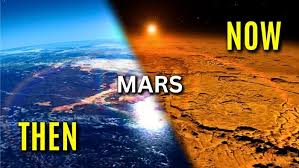

In [11]:
# Step 1 — Real headline
real_headline = "NASA confirms water found on Mars surface"

# Step 2 — Load real image
real_image = Image.open("/Users/rakeshraushan/Ankit/SENTINEL/test_image_m1.jpeg")
print("Image loaded! Size:", real_image.size)
real_image

In [12]:
# Step 3 — Get text vector from headline
text_tokens = tokenizer(
    real_headline,
    return_tensors='pt',
    max_length=512,
    truncation=True,
    padding=True
)

with torch.no_grad():
    text_output = model(**text_tokens)
    
real_text_vector = text_output.last_hidden_state[:, 0, :]

# Step 4 — Get image vector from mars image
real_image_input = preprocess(real_image).unsqueeze(0)

with torch.no_grad():
    real_image_vector = clip_model.encode_image(real_image_input)

# Step 5 — Run through Cross-Modal Attention
real_output, real_attention = fusion_model(real_text_vector, real_image_vector)
real_probs = torch.softmax(real_output, dim=-1)

# Results
print("=" * 50)
print("SENTINEL Module 1 — Real Data Test")
print("=" * 50)
print(f"Headline: {real_headline}")
print()
print(f"Text vector shape:  {real_text_vector.shape}")
print(f"Image vector shape: {real_image_vector.shape}")
print()
print(f"P(Real):  {real_probs[0][0].item():.4f}")
print(f"P(Fake):  {real_probs[0][1].item():.4f}")
print()
prediction = "FAKE" if real_probs[0][1] > 0.5 else "REAL"
print(f"Prediction: {prediction}")
print()
print("Note: untrained model — prediction is random.")
print("After training on FakeNewsNet this will be meaningful!")

SENTINEL Module 1 — Real Data Test
Headline: NASA confirms water found on Mars surface

Text vector shape:  torch.Size([1, 768])
Image vector shape: torch.Size([1, 512])

P(Real):  0.5303
P(Fake):  0.4697

Prediction: REAL

Note: untrained model — prediction is random.
After training on FakeNewsNet this will be meaningful!


In [13]:
# Step 3 — Get text vector
text_tokens = tokenizer(
    real_headline,
    return_tensors='pt',
    max_length=512,
    truncation=True,
    padding=True
)
with torch.no_grad():
    text_output = model(**text_tokens)
real_text_vector = text_output.last_hidden_state[:, 0, :]

# Step 4 — Get image vector
real_image_input = preprocess(real_image).unsqueeze(0)
with torch.no_grad():
    real_image_vector = clip_model.encode_image(real_image_input)

# Step 5 — Run through fusion model
real_output, real_attention = fusion_model(real_text_vector, real_image_vector)
real_probs = torch.softmax(real_output, dim=-1)

# Results
print("=" * 50)
print("SENTINEL Module 1 — Real Data Test")
print("=" * 50)
print(f"Headline: {real_headline}")
print()
print(f"Text vector shape:    {real_text_vector.shape}")
print(f"Image vector shape:   {real_image_vector.shape}")
print(f"Attention score:      {real_attention.item():.4f}")
print()
print(f"P(Real):  {real_probs[0][0].item():.4f}")
print(f"P(Fake):  {real_probs[0][1].item():.4f}")
prediction = "FAKE" if real_probs[0][1] > 0.5 else "REAL"
print(f"Prediction: {prediction}")
print()
print("Remember: untrained model = random prediction")
print("Training on FakeNewsNet will make this meaningful!")

SENTINEL Module 1 — Real Data Test
Headline: NASA confirms water found on Mars surface

Text vector shape:    torch.Size([1, 768])
Image vector shape:   torch.Size([1, 512])
Attention score:      1.0000

P(Real):  0.5303
P(Fake):  0.4697
Prediction: REAL

Remember: untrained model = random prediction
Training on FakeNewsNet will make this meaningful!
